Distribución de etiquetas:
y
0    100
1    100
Name: count, dtype: int64


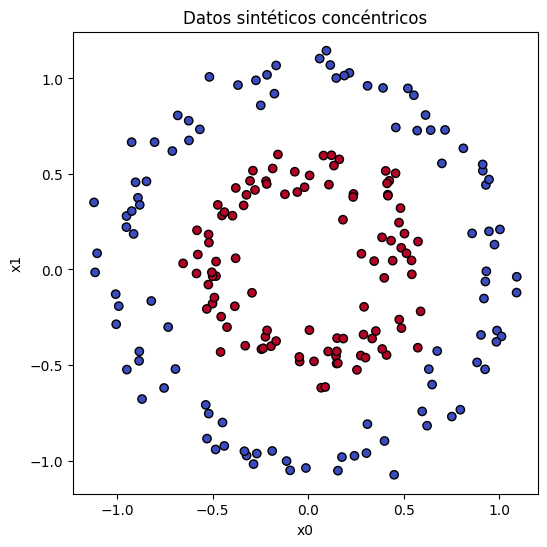

,x0,x1,y
0,0.905080,-0.342737,0
1,0.614971,0.808427,0
2,-0.247633,0.859073,0
3,-0.500180,-0.179026,1
4,-0.157837,0.601865,1


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=200,
    factor=0.5,
    noise=0.08,
    random_state=42,
)

datos = pd.DataFrame(X, columns=["x0", "x1"])
datos["y"] = y

print("Distribución de etiquetas:")
print(datos["y"].value_counts().sort_index())

plt.figure(figsize=(6, 6))
plt.scatter(datos["x0"], datos["x1"], c=datos["y"], cmap="coolwarm", edgecolor="black")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Datos sintéticos concéntricos")
plt.axis("equal")
plt.show()

datos.head()

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.20.0


In [10]:
!nvidia-smi

Wed Aug 26 16:42:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             28W /   70W |     381MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
modelo = models.Sequential([
    layers.Input(shape=(2,), name="entradas_x0_x1"),
    layers.Dense(16, activation="relu", name="oculta_16"),
    layers.Dense(8, activation="relu", name="oculta_8"),
    layers.Dense(4, activation="relu", name="oculta_4"),
    layers.Dense(1, activation="sigmoid", name="salida")
])

modelo.compile(
    optimizer=optimizers.Adam(),
    loss=losses.BinaryCrossentropy(),
    metrics=[metrics.BinaryAccuracy(name="exactitud")]
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_16 (Dense)               │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_8 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_4 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
prube = modelo

y_binaria = y.reshape(-1, 1)

prube.compile(
    optimizer=optimizers.Adam(learning_rate=0.03),
    loss="binary_crossentropy",
    metrics=["mse", "binary_crossentropy"]
)

historial = prube.fit(
    X,
    y_binaria,
    epochs=100,
    verbose=0
)

resultados = prube.evaluate(X, y_binaria, verbose=0, return_dict=True)
print(f"MSE: {resultados['mse']:.4f}")
print(f"Binary Cross-Entropy: {resultados['binary_crossentropy']:.4f}")

MSE: 0.0000
Binary Cross-Entropy: 0.0007


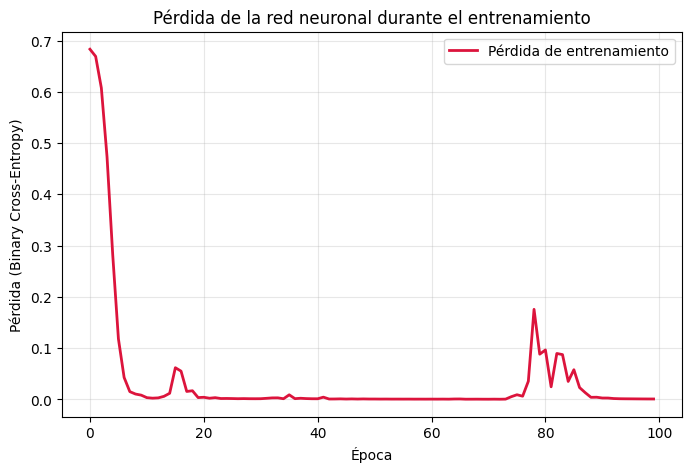

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(historial.history["loss"], color="crimson", linewidth=2, label="Pérdida de entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida (Binary Cross-Entropy)")
plt.title("Pérdida de la red neuronal durante el entrenamiento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
for capa in prube.layers:
    pesos, bias = capa.get_weights()
    print(f"\nCapa: {capa.name}")
    print("Pesos finales:")
    print(pesos)
    print("Bias finales:")
    print(bias)


Capa: oculta_16
Pesos finales:
[[-6.7617454e-02 -1.4161236e+00 -4.7499504e-02  8.6928207e-01
   3.5436752e-01 -1.0850158e+00 -1.0785235e+00  1.6250919e+00
  -3.9403480e-01  1.3088063e+00 -5.2509028e-02  3.8040560e-02
  -1.0205356e+00 -8.0221814e-01 -4.3228203e-01  1.1938796e+00]
 [ 1.2625471e+00  4.8707646e-01  1.6613269e-03  7.6095653e-01
  -1.0458326e+00  3.4649462e-01  2.9521731e-01 -2.4186778e-01
   1.0690110e+00  5.2804655e-01  1.5572506e+00 -5.0097555e-02
  -1.0535523e+00  7.0082295e-01 -1.9110378e+00 -6.1065733e-01]]
Bias finales:
[-0.5884065  -0.5072677  -0.21480207 -0.54488146 -0.57884824 -0.5440453
 -0.5077133  -0.5502501  -0.5510624  -0.48743168 -0.5931119  -0.4233071
 -0.6843105  -0.6787557  -0.35911337 -0.5825097 ]

Capa: oculta_8
Pesos finales:
[[ 1.1971245   0.24468207 -0.46983135  1.0290859  -0.5469055   1.1191711
   0.04807283 -1.0763562 ]
 [ 0.8335653   0.09310853 -0.2596816   1.5601319  -0.0779645   0.5029057
  -0.26506886 -1.0566763 ]
 [ 0.1671884  -0.47283435 -0.1

In [14]:
from tensorflow import keras

ruta_modelo = "prube_final.keras"

prube.save(ruta_modelo)

prube_persistido = keras.models.load_model(ruta_modelo)

pesos_originales = prube.get_weights()
pesos_persistidos = prube_persistido.get_weights()
pesos_conservados = all(
    np.array_equal(original, persistido)
    for original, persistido in zip(pesos_originales, pesos_persistidos)
)

print(f"Modelo guardado con Keras en: {ruta_modelo}")
print(f"Últimos pesos conservados: {pesos_conservados}")

Modelo guardado con Keras en: prube_final.keras
Últimos pesos conservados: True
